In [3]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv1D, BatchNormalization,
    ReLU, Add, GlobalAveragePooling1D, Dense
)
from tensorflow.keras.models import Model



AttributeError: partially initialized module 'pandas' has no attribute 'core' (most likely due to a circular import)

In [2]:
data = np.load(
    "preprocessingW64S64binaryfloat32/tow_ids_binary_preprocessedW64S64.npz",
    mmap_mode="r"   # penting: tidak load penuh ke RAM
)

print(data.files)

['x_train', 'y_train', 'x_val', 'y_val', 'x_test', 'y_test']


In [ ]:
data = np.load("preprocessingW64S64binaryfloat32/tow_ids_binary_preprocessedW64S64.npz")

X_train = data["x_train"]
y_train = data["y_train"]
X_val   = data["x_val"]
y_val   = data["y_val"]
X_test  = data["x_test"]
y_test  = data["y_test"]

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)


(13165, 64, 64) (13165,)
(5643, 64, 64) (5643,)
(12368, 64, 64) (12368,)


In [7]:
np.unique(y_train, return_counts=True)

(array([0, 1]), array([6011, 7154]))

In [4]:
import numpy as np

# Fungsi untuk cek balance
def check_balance_binary(y):
    n_normal = np.sum(y == 0)
    n_attack = np.sum(y == 1)
    total = len(y)
    print(f"Total samples: {total}")
    print(f"Normal: {n_normal} ({n_normal/total*100:.2f}%)")
    print(f"Attack: {n_attack} ({n_attack/total*100:.2f}%)\n")

# Cek balance di masing-masing split
print("=== Train Set ===")
check_balance_binary(y_train)

print("=== Validation Set ===")
check_balance_binary(y_val)

print("=== Test Set ===")
check_balance_binary(y_test)


=== Train Set ===
Total samples: 13165
Normal: 6011 (45.66%)
Attack: 7154 (54.34%)

=== Validation Set ===
Total samples: 5643
Normal: 2576 (45.65%)
Attack: 3067 (54.35%)

=== Test Set ===
Total samples: 12368
Normal: 6846 (55.35%)
Attack: 5522 (44.65%)



In [5]:
def tcn_block(x, filters, kernel_size, dilation):
    shortcut = x

    x = Conv1D(filters, kernel_size,
               padding="causal",
               dilation_rate=dilation)(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    x = Conv1D(filters, kernel_size,
               padding="causal",
               dilation_rate=dilation)(x)
    x = BatchNormalization()(x)

    if shortcut.shape[-1] != filters:
        shortcut = Conv1D(filters, 1, padding="same")(shortcut)

    x = Add()([x, shortcut])
    x = ReLU()(x)
    return x


In [8]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dropout, MaxPooling1D, Flatten, Dense

def build_mr_tcn(input_shape=(64, 64), dropout_rate=0.00):
    model = Sequential()

    # Conv1D #1
    model.add(Conv1D(
        filters=64,
        kernel_size=3,
        strides=1,
        dilation_rate=1,
        padding="same",
        activation="relu",
        input_shape=input_shape
    ))
    model.add(Dropout(dropout_rate))

    # Conv1D #2
    model.add(Conv1D(
        filters=64,
        kernel_size=3,
        strides=1,
        dilation_rate=2,
        padding="same",
        activation="relu"
    ))
    model.add(Dropout(dropout_rate))

    # Conv1D #3
    model.add(Conv1D(
        filters=64,
        kernel_size=3,
        strides=1,
        dilation_rate=4,
        padding="same",
        activation="relu"
    ))
    model.add(Dropout(dropout_rate))

    # MaxPooling
    model.add(MaxPooling1D(pool_size=8, strides=8))

    # Flatten
    model.add(Flatten())

    # Dropout
    model.add(Dropout(dropout_rate))

    # Linear → Sigmoid
    model.add(Dense(1, activation="sigmoid"))

    return model


In [9]:
model = build_mr_tcn()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()


/home/dani/miniconda3/envs/latihan1/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1767159922.173383  327004 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4136 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 64, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 64, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 64, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 8, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,569 (146.75 KB)

 Trainable params: 37,569 (146.75 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=30,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_mr_tcn.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)


In [11]:

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=700,
    batch_size=64,
    callbacks=[early_stop, checkpoint]
)



Epoch 1/700


I0000 00:00:1767159930.818149  328600 service.cc:152] XLA service 0x76e3cc01b3f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1767159930.818166  328600 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6
2025-12-31 12:45:30.841362: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1767159930.987493  328600 cuda_dnn.cc:529] Loaded cuDNN version 91200


 94/206 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4781 - loss: 0.6996

I0000 00:00:1767159932.086224  328600 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


206/206 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4950 - loss: 0.6964
Epoch 1: val_loss improved from None to 0.68235, saving model to best_mr_tcn.keras
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.5212 - loss: 0.6911 - val_accuracy: 0.5626 - val_loss: 0.6824
Epoch 2/700
192/206 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5866 - loss: 0.6779
Epoch 2: val_loss improved from 0.68235 to 0.66569, saving model to best_mr_tcn.keras
206/206 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5973 - loss: 0.6734 - val_accuracy: 0.6192 - val_loss: 0.6657
Epoch 3/700
203/206 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6511 - loss: 0.6592
Epoch 3: val_loss improved from 0.66569 to 0.64818, saving model to best_mr_tcn.keras
206/206 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6596 - loss: 0.6563 - val_accuracy: 0.6821 - val_loss: 0.6482
Epoch 4/700
178/206 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7090 - loss: 0.6437
Epoch 4: val_loss improved from 0.64818 to 0.62914, savin

In [12]:
test_results = model.evaluate(X_test, y_test, verbose=0)

for name, val in zip(model.metrics_names, test_results):
    print(f"{name}: {val:.4f}")


loss: 0.3869
compile_metrics: 0.8435


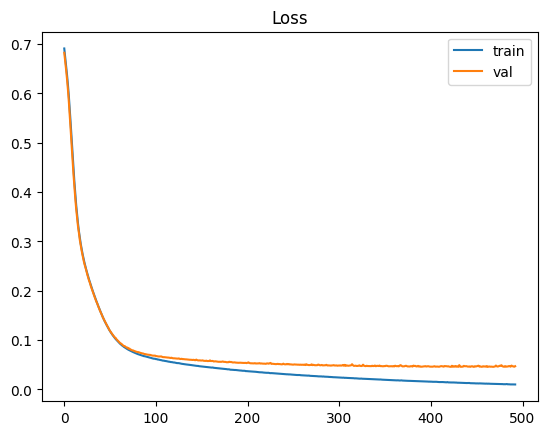

In [13]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.legend()
plt.title("Loss")
plt.show()


In [14]:
# ===== EVALUASI MODEL (TEST SET) =====

import numpy as np
from sklearn.metrics import roc_curve, confusion_matrix, classification_report

# 1. Ambil probabilitas output model
y_prob = model.predict(X_test).ravel()

# 2. Hitung ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# 3. Hitung Youden Index
youden_index = tpr - fpr
best_threshold = thresholds[np.argmax(youden_index)]

print("Best threshold (Youden):", best_threshold)

# 4. Prediksi final menggunakan threshold Youden
y_pred = (y_prob >= best_threshold).astype(int)

# 5. Evaluasi
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Normal", "Attack"]))


387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Best threshold (Youden): 0.88943523
Confusion Matrix:
[[6554  292]
 [1118 4404]]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.85      0.96      0.90      6846
      Attack       0.94      0.80      0.86      5522

    accuracy                           0.89     12368
   macro avg       0.90      0.88      0.88     12368
weighted avg       0.89      0.89      0.88     12368



In [15]:
y_pred = (y_prob >= best_threshold)


In [16]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=["Normal","Attack"]))


              precision    recall  f1-score   support

      Normal       0.85      0.96      0.90      6846
      Attack       0.94      0.80      0.86      5522

    accuracy                           0.89     12368
   macro avg       0.90      0.88      0.88     12368
weighted avg       0.89      0.89      0.88     12368



--- Memulai Proses Evaluasi ---
387/387 ━━━━━━━━━━━━━━━━━━━━ 0s 850us/step


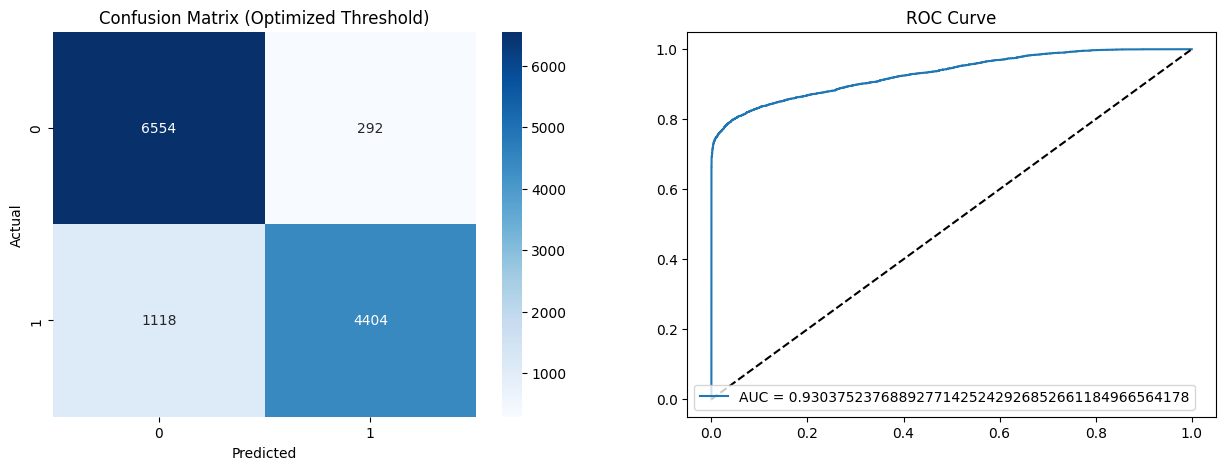


HASIL EVALUASI IDS (IoV)
Threshold Optimal : 0.8894
False Positive Rate: 0.042653
Inference Latency : 0.000043 s/sample
------------------------------
              precision    recall  f1-score   support

      Normal       0.85      0.96      0.90      6846
      Attack       0.94      0.80      0.86      5522

    accuracy                           0.89     12368
   macro avg       0.90      0.88      0.88     12368
weighted avg       0.89      0.89      0.88     12368



In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report

# 1. DEFINISI FUNGSI (Mesin Evaluasi)
def evaluate_iov_model(model, X_test, y_test):
    print("--- Memulai Proses Evaluasi ---")
    
    # Prediksi
    start_time = time.time()
    y_prob = model.predict(X_test).ravel()
    inference_time = (time.time() - start_time) / len(X_test)
    
    # Mencari Threshold Terbaik (Youden Index)
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    youden_index = tpr - fpr
    best_threshold = thresholds[np.argmax(youden_index)]
    
    # Klasifikasi Berdasarkan Threshold
    y_pred = (y_prob >= best_threshold).astype(int)
    
    # Hitung Metrik
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    fpr_val = fp / (fp + tn)
    
    # VISUALISASI
    fig, ax = plt.subplots(1, 2, figsize=(15, 5))
    
    # Heatmap Confusion Matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0])
    ax[0].set_title('Confusion Matrix (Optimized Threshold)')
    ax[0].set_xlabel('Predicted')
    ax[0].set_ylabel('Actual')
    
    # ROC Curve
    ax[1].plot(fpr, tpr, label=f'AUC = {auc(fpr, tpr):.44f}')
    ax[1].plot([0, 1], [0, 1], 'k--')
    ax[1].set_title('ROC Curve')
    ax[1].legend()
    
    plt.show() # Ini akan memunculkan gambar
    
    # CETAK HASIL KE KONSOL
    print("\n" + "="*30)
    print(f"HASIL EVALUASI IDS (IoV)")
    print("="*30)
    print(f"Threshold Optimal : {best_threshold:.4f}")
    print(f"False Positive Rate: {fpr_val:.6f}")
    print(f"Inference Latency : {inference_time:.6f} s/sample")
    print("-" * 30)
    print(classification_report(y_test, y_pred, target_names=['Normal', 'Attack']))
    
    return best_threshold

# ==========================================
# 2. EKSEKUSI FUNGSI (Panggil di sini)
# ==========================================
# Ganti 'model_anda', 'X_test_anda', 'y_test_anda' 
# dengan nama variabel yang Anda miliki.

try:
    # Contoh: jika model Anda bernama 'global_model'
    best_thr = evaluate_iov_model(model, X_test, y_test)
except NameError as e:
    print(f"Error: {e}. Pastikan variabel model dan data Anda sudah didefinisikan sebelumnya.")

In [18]:
from sklearn.metrics import confusion_matrix

# 1. Dapatkan prediksi dari model (berupa probabilitas)
y_prob = model.predict(X_test) 

# 2. Ubah probabilitas menjadi kelas (0 atau 1) 
# Gunakan threshold, misalnya 0.5 atau hasil Youden Index
y_pred = (y_prob > best_threshold).astype(int)

# 3. Munculkan Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# 4. Ekstrak TP, FP, TN, FN dari matriks
# Matriks sklearn memiliki format: [[TN, FP], [FN, TP]]
tn, fp, fn, tp = cm.ravel()

# 5. Cetak ke layar
print(f"--- Hasil Deteksi Serangan ---")
print(f"True Negatives (TN)  : {tn} (Trafik normal terdeteksi normal)")
print(f"False Positives (FP) : {fp} (ALARM PALSU - Normal dianggap serangan)")
print(f"False Negatives (FN) : {fn} (LOLOS - Serangan dianggap normal)")
print(f"True Positives (TP)  : {tp} (Berhasil mendeteksi serangan)")

387/387 ━━━━━━━━━━━━━━━━━━━━ 0s 718us/step
--- Hasil Deteksi Serangan ---
True Negatives (TN)  : 6554 (Trafik normal terdeteksi normal)
False Positives (FP) : 292 (ALARM PALSU - Normal dianggap serangan)
False Negatives (FN) : 1119 (LOLOS - Serangan dianggap normal)
True Positives (TP)  : 4403 (Berhasil mendeteksi serangan)


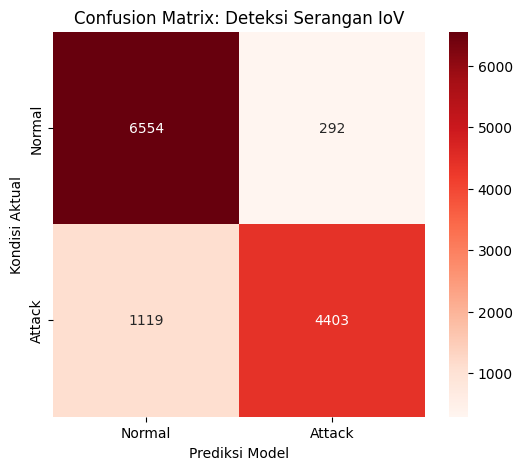

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Normal', 'Attack'], 
            yticklabels=['Normal', 'Attack'])
plt.title('Confusion Matrix: Deteksi Serangan IoV')
plt.ylabel('Kondisi Aktual')
plt.xlabel('Prediksi Model')
plt.show()

batas


In [20]:
import numpy as np

y_prob = model.predict(X_test).ravel()      # probabilitas Attack
y_pred = (y_prob > best_threshold).astype(int)         # label prediksi (threshold default)


387/387 ━━━━━━━━━━━━━━━━━━━━ 0s 821us/step


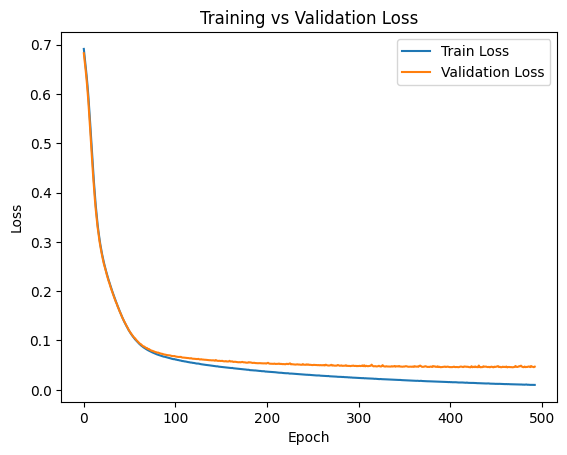

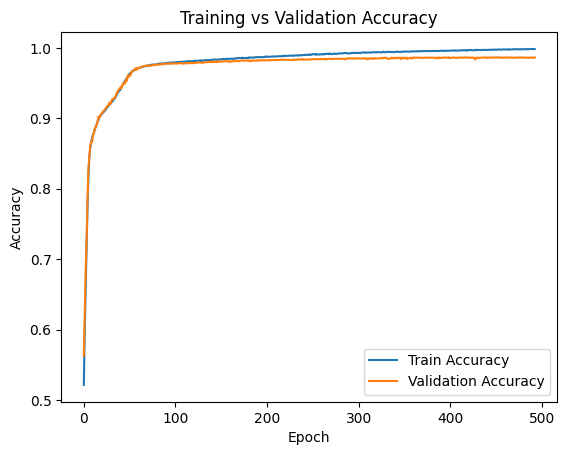

In [21]:
# Fungsi: deteksi overfitting dan stabilitas training.
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()


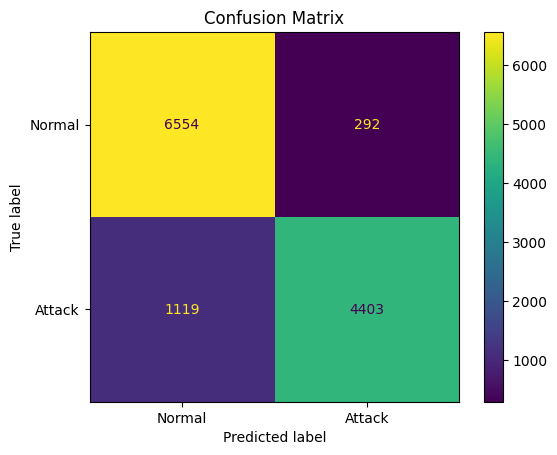

In [22]:
# Fungsi: melihat False Negative (serangan lolos).
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Attack"]
)
disp.plot()
plt.title("Confusion Matrix")
plt.show()
# 📌 Interpretasi IDS

# FN (Attack → Normal) harus minimal

# FP tinggi → false alarm

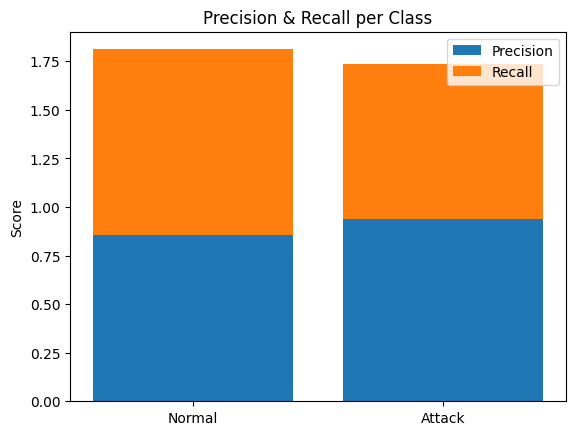

In [23]:
# Fungsi: menilai kualitas deteksi Attack.
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, _ = precision_recall_fscore_support(
    y_test, y_pred, average=None
)

labels = ["Normal", "Attack"]

plt.figure()
plt.bar(labels, precision, label="Precision")
plt.bar(labels, recall, bottom=precision, label="Recall")
plt.ylabel("Score")
plt.title("Precision & Recall per Class")
plt.legend()
plt.show()
# Fokus laporan: Recall kelas Attack


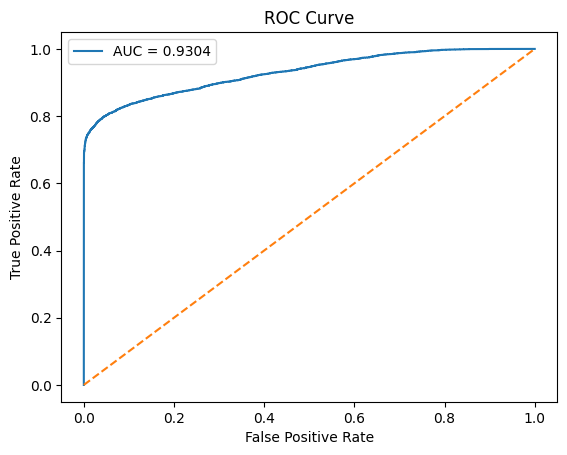

In [24]:
# Fungsi: evaluasi threshold-independent.
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# AUC mendekati 1 → IDS sangat kuat


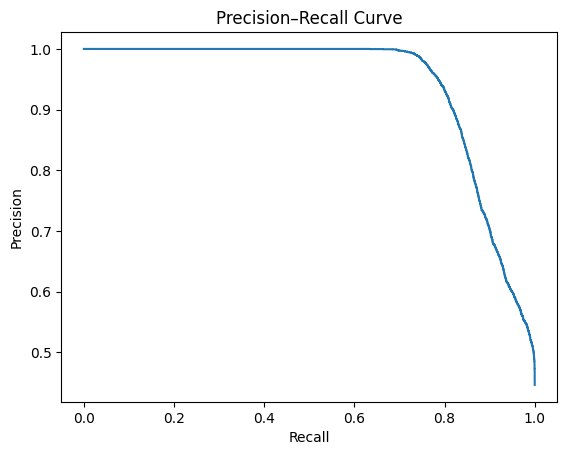

In [25]:
# Lebih relevan dari ROC untuk IDS.
from sklearn.metrics import precision_recall_curve

prec, rec, _ = precision_recall_curve(y_test, y_prob)

plt.figure()
plt.plot(rec, prec)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.show()


In [26]:
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# ASUMSI:
# - y_prob SUDAH dihitung di evaluate_iov_model
# - best_thr didapat dari return fungsi
# ==========================================

# Gunakan ulang y_prob & y_test (TIDAK buat baru)
y_pred = (y_prob >= best_thr).astype(int)

# Hitung F1-score untuk threshold yang SAMA
f1 = f1_score(y_test, y_pred)

print("\n" + "="*30)
print("F1-SCORE (FOLLOW YOUDEN THRESHOLD)")
print("="*30)
print(f"Threshold digunakan : {best_thr:.4f}")
print(f"F1-score           : {f1:.6f}")



F1-SCORE (FOLLOW YOUDEN THRESHOLD)
Threshold digunakan : 0.8894
F1-score           : 0.862008


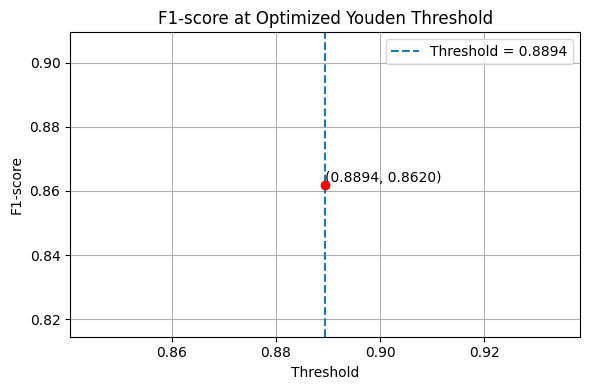

In [27]:
plt.figure(figsize=(6,4))
plt.scatter(best_thr, f1, color='red', zorder=5)
plt.axvline(best_thr, linestyle='--', label=f"Threshold = {best_thr:.4f}")

plt.text(
    best_thr, f1,
    f"({best_thr:.4f}, {f1:.4f})",
    ha='left', va='bottom'
)

plt.xlabel("Threshold")
plt.ylabel("F1-score")
plt.title("F1-score at Optimized Youden Threshold")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


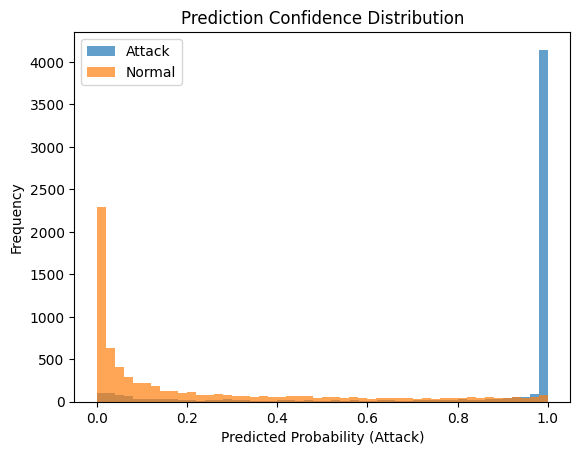

In [28]:
# Fungsi: lihat separasi Normal vs Attack.
plt.figure()
plt.hist(y_prob[y_test == 1], bins=50, alpha=0.7, label="Attack")
plt.hist(y_prob[y_test == 0], bins=50, alpha=0.7, label="Normal")
plt.xlabel("Predicted Probability (Attack)")
plt.ylabel("Frequency")
plt.title("Prediction Confidence Distribution")
plt.legend()
plt.show()
# 📌 Distribusi terpisah jelas → model robust.

In [29]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test, y_pred,
    target_names=["Normal", "Attack"]
))


              precision    recall  f1-score   support

      Normal       0.85      0.96      0.90      6846
      Attack       0.94      0.80      0.86      5522

    accuracy                           0.89     12368
   macro avg       0.90      0.88      0.88     12368
weighted avg       0.89      0.89      0.88     12368



In [30]:
import numpy as np
from sklearn.metrics import confusion_matrix

def compute_ids_metrics(y_true, y_pred):
    """
    Compute IDS metrics exactly as defined in the paper:
    Acc, F1, FPR, FNR
    """

    # Confusion Matrix
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    # Metrics (paper definitions)
    acc = (tp + tn) / (tp + tn + fp + fn)
    f1  = (2 * tp) / (2 * tp + fp + fn)
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0

    return {
        "TP": tp,
        "FP": fp,
        "TN": tn,
        "FN": fn,
        "Accuracy": acc,
        "F1-score": f1,
        "FPR": fpr,
        "FNR": fnr,
        "FNR": fnr,
    }


In [31]:

# Hitung metrik IDS
metrics = compute_ids_metrics(y_test, y_pred)

for k, v in metrics.items():
    print(f"{k:10s}: {v:.6f}" if isinstance(v, float) else f"{k:10s}: {v}")


TP        : 4404
FP        : 292
TN        : 6554
FN        : 1118
Accuracy  : 0.885996
F1-score  : 0.862008
FPR       : 0.042653
FNR       : 0.202463


HASIL DARI MRCTN-AE W64 S64 D0.00